In [1]:
import pandas as pd
import numpy as np

In [12]:
# # The main speciality of Prophet is that it is designed to make time-series forecasting with
# # trend + multiple seasonal patterns + holidays/events + optional external regressors relatively easy.

# # Prophet
# #   ↓
# # Trend
# # + Daily seasonality
# # + Weekly seasonality
# # + Yearly seasonality
# # + Holidays/events
# # + Optional external regressors
# it is primarily univariate time-series analysis.

# Univariate: You forecast one target variable (y) using time (ds) and its historical values.

In [3]:
import yfinance as yf

In [4]:
data=yf.download('BABA',start='2024-01-01')

[*********************100%***********************]  1 of 1 completed


In [5]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,BABA,BABA,BABA,BABA,BABA
Date,,,,,
2024-01-02,71.298813,72.552927,71.060387,72.529090,21739600
2024-01-03,73.044083,73.139459,70.640755,70.888720,24444600
2024-01-04,71.203445,72.219134,70.993630,72.061772,18454900
2024-01-05,69.629837,70.574001,69.486780,70.574001,21725200
2024-01-08,69.505844,69.677511,67.636588,67.951311,22000000


In [6]:
data.shape

(667, 5)

In [7]:
data.isnull().sum()

Price   Ticker
Close   BABA      1
High    BABA      1
Low     BABA      1
Open    BABA      1
Volume  BABA      0
dtype: int64

In [8]:
data.columns

MultiIndex([( 'Close', 'BABA'),
            (  'High', 'BABA'),
            (   'Low', 'BABA'),
            (  'Open', 'BABA'),
            ('Volume', 'BABA')],
           names=['Price', 'Ticker'])

In [9]:
data.dropna(inplace=True)

In [10]:
data=data.iloc[:,:-1]

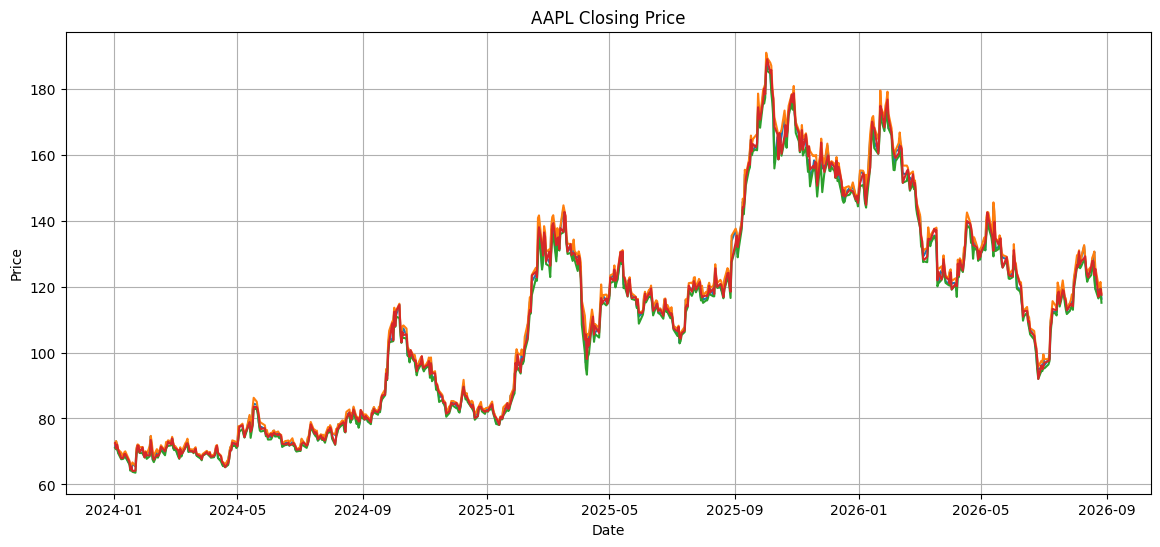

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
plt.plot(data)

plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()


In [13]:
df=data[["Close"]].copy()

In [14]:
df

Price,Close
Ticker,BABA
Date,
2024-01-02,71.298813
2024-01-03,73.044083
2024-01-04,71.203445
2024-01-05,69.629837
2024-01-08,69.505844
...,...
2026-08-21,119.339996
2026-08-24,118.470001


In [15]:
df1 = data[["Close"]].reset_index()

In [16]:
df1

Price,Date,Close
Ticker,,BABA
0,2024-01-02,71.298813
1,2024-01-03,73.044083
2,2024-01-04,71.203445
3,2024-01-05,69.629837
4,2024-01-08,69.505844
...,...,...
661,2026-08-21,119.339996
662,2026-08-24,118.470001
663,2026-08-25,119.440002


In [17]:
prophet_df = pd.DataFrame({
    "ds": df1["Date"].copy(),
    "y": df1["Close"]["BABA"].copy()
})

In [18]:
prophet_df

,ds,y
0,2024-01-02,71.298813
1,2024-01-03,73.044083
2,2024-01-04,71.203445
3,2024-01-05,69.629837
4,2024-01-08,69.505844
...,...,...
661,2026-08-21,119.339996
662,2026-08-24,118.470001
663,2026-08-25,119.440002
664,2026-08-26,119.830002


In [19]:
prophet_df.head()

,ds,y
0,2024-01-02,71.298813
1,2024-01-03,73.044083
2,2024-01-04,71.203445
3,2024-01-05,69.629837
4,2024-01-08,69.505844


In [20]:
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

In [21]:
prophet_df.head()

,ds,y
0,2024-01-02,71.298813
1,2024-01-03,73.044083
2,2024-01-04,71.203445
3,2024-01-05,69.629837
4,2024-01-08,69.505844


In [22]:
split_date = "2026-01-01"

train = prophet_df[prophet_df["ds"] < split_date].copy()
test = prophet_df[prophet_df["ds"] >= split_date].copy()

In [23]:
train

,ds,y
0,2024-01-02,71.298813
1,2024-01-03,73.044083
2,2024-01-04,71.203445
3,2024-01-05,69.629837
4,2024-01-08,69.505844
...,...,...
497,2025-12-24,148.694397
498,2025-12-26,150.854568
499,2025-12-29,147.138687
500,2025-12-30,146.018967


In [24]:
test.tail()

,ds,y
661,2026-08-21,119.339996
662,2026-08-24,118.470001
663,2026-08-25,119.440002
664,2026-08-26,119.830002
665,2026-08-27,116.309998


In [25]:
from prophet import Prophet

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates


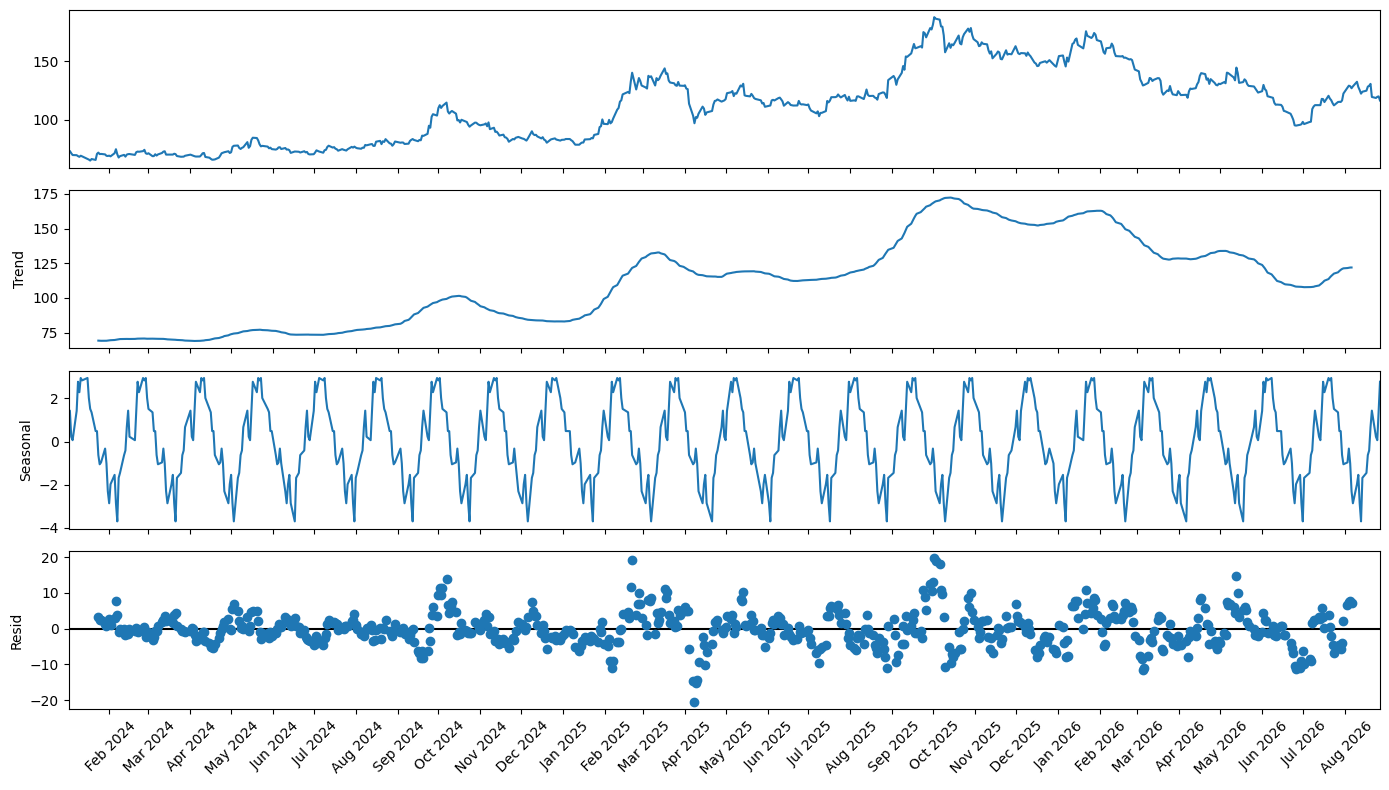

In [27]:
result = seasonal_decompose(df["Close"],model="additive",period=30)
fig = result.plot()
fig.set_size_inches(14, 8)
# Format the dates
for ax in fig.axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(" %b %Y"))
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [28]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from itertools import product

In [29]:
param_grid = {
    "growth": ["linear", "flat"],
    "n_changepoints": [10, 25, 50],
    "changepoint_range": [0.8, 0.9],
    "changepoint_prior_scale": [0.01, 0.05, 0.1],
    "seasonality_prior_scale": [1, 10],
    "seasonality_mode": ["additive", "multiplicative"]
}

In [55]:
keys = param_grid.keys()

all_params = [
    dict(zip(keys, values))
    for values in product(*param_grid.values())
]

results = []

for params in all_params:

    model = Prophet(
        **params,
        yearly_seasonality="auto",
        weekly_seasonality="auto",
        daily_seasonality="auto",
        interval_width=0.95,
        uncertainty_samples=1000,
        mcmc_samples=0
    )
    model.add_seasonality(
        name="monthly",
        period=45,
        fourier_order=5
    )
#fourier_order determines how many Fourier terms Prophet uses to describe the shape of a seasonal cycle; 
    #higher values allow more detailed patterns but increase the risk of overfitting.
    # Custom seasonality example
    model.add_seasonality(
        name="custom_seasonality",
        period=40,
        fourier_order=5
    )

In [56]:
model.fit(train)

df_cv = cross_validation(
    model,
    initial="365 days",#minimum amount of historical data used for the first training period.
    period="30 days",#how frequently Prophet creates a new cutoff/training-test split.
    horizon="90 days"#This is the forecast/test period.
)

df_p = performance_metrics(
    df_cv,
    rolling_window=1
)

results.append({
    **params,
    "rmse": df_p["rmse"].mean(),
    "mae": df_p["mae"].mean(),
    "mape": df_p["mape"].mean()
})

results_df = pd.DataFrame(results)

16:01:45 - cmdstanpy - INFO - Chain [1] start processing
16:01:46 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/10 [00:00<?, ?it/s]

16:01:46 - cmdstanpy - INFO - Chain [1] start processing
16:01:46 - cmdstanpy - INFO - Chain [1] done processing
16:01:46 - cmdstanpy - INFO - Chain [1] start processing
16:01:46 - cmdstanpy - INFO - Chain [1] done processing
16:01:47 - cmdstanpy - INFO - Chain [1] start processing
16:01:47 - cmdstanpy - INFO - Chain [1] done processing
16:01:47 - cmdstanpy - INFO - Chain [1] start processing
16:01:47 - cmdstanpy - INFO - Chain [1] done processing
16:01:47 - cmdstanpy - INFO - Chain [1] start processing
16:01:47 - cmdstanpy - INFO - Chain [1] done processing
16:01:47 - cmdstanpy - INFO - Chain [1] start processing
16:01:48 - cmdstanpy - INFO - Chain [1] done processing
16:01:48 - cmdstanpy - INFO - Chain [1] start processing
16:01:48 - cmdstanpy - INFO - Chain [1] done processing
16:01:48 - cmdstanpy - INFO - Chain [1] start processing
16:01:48 - cmdstanpy - INFO - Chain [1] done processing
16:01:48 - cmdstanpy - INFO - Chain [1] start processing
16:01:48 - cmdstanpy - INFO - Chain [1]

In [57]:
results_df

,growth,n_changepoints,changepoint_range,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,rmse,mae,mape
0,flat,50,0.9,0.1,10,multiplicative,48.699783,43.993594,0.318235


In [58]:
model = Prophet(
    growth="flat",
    yearly_seasonality='auto',
    weekly_seasonality='auto',
    daily_seasonality='auto',
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.1,
    changepoint_range=0.9,
    seasonality_prior_scale=10,
    interval_width=0.95,
    n_changepoints=50
)
model.add_seasonality(
        name="monthly",
        period=30.5,
        fourier_order=5
    )
model.add_seasonality(
        name="custom_seasonality",
        period=45,
        fourier_order=5
    )

In [59]:
model.fit(train)

16:02:10 - cmdstanpy - INFO - Chain [1] start processing
16:02:10 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
future = test[["ds"]].copy()

In [61]:
forecast = model.predict(future)

In [62]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,custom_seasonality,custom_seasonality_lower,custom_seasonality_upper,monthly,...,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,weekly,weekly_lower,weekly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2026-01-02,104.425218,43.787330,161.239758,104.425218,104.425218,-0.006445,-0.006445,-0.006445,0.001519,...,-0.007146,-0.007146,-0.007146,-0.002221,-0.002221,-0.002221,0.0,0.0,0.0,103.678987
1,2026-01-05,104.425218,44.999484,164.704670,104.425218,104.425218,-0.023948,-0.023948,-0.023948,-0.001890,...,-0.018332,-0.018332,-0.018332,0.007506,0.007506,0.007506,0.0,0.0,0.0,102.510851
2,2026-01-06,104.425218,34.440226,162.239790,104.425218,104.425218,-0.031196,-0.031196,-0.031196,-0.015728,...,-0.050372,-0.050372,-0.050372,-0.003448,-0.003448,-0.003448,0.0,0.0,0.0,99.165142
3,2026-01-07,104.425218,37.364874,157.988057,104.425218,104.425218,-0.038844,-0.038844,-0.038844,-0.025377,...,-0.058502,-0.058502,-0.058502,0.005719,0.005719,0.005719,0.0,0.0,0.0,98.316107
4,2026-01-08,104.425218,33.384370,153.786665,104.425218,104.425218,-0.045772,-0.045772,-0.045772,-0.024061,...,-0.077560,-0.077560,-0.077560,-0.007727,-0.007727,-0.007727,0.0,0.0,0.0,96.326019


In [63]:
forecast.shape

(164, 22)

In [64]:
results = test.merge(
    forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ],
    on="ds"
)

In [65]:
results

,ds,y,yhat,yhat_lower,yhat_upper
0,2026-01-02,154.322708,103.678987,43.787330,161.239758
1,2026-01-05,154.837967,102.510851,44.999484,164.704670
2,2026-01-06,149.526749,99.165142,34.440226,162.239790
3,2026-01-07,145.414520,98.316107,37.364874,157.988057
4,2026-01-08,153.064270,96.326019,33.384370,153.786665
...,...,...,...,...,...
159,2026-08-21,119.339996,98.670711,35.768509,158.800056
160,2026-08-24,118.470001,101.168207,37.443109,162.281140
161,2026-08-25,119.440002,99.809963,41.292978,163.068544
162,2026-08-26,119.830002,100.706644,41.735316,159.790514


In [66]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    results["y"],
    results["yhat"]
)

print("MAE:", mae)

MAE: 28.773770544518793


In [67]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        results["y"],
        results["yhat"]
    )
)

print("RMSE:", rmse)

RMSE: 33.74459031236418


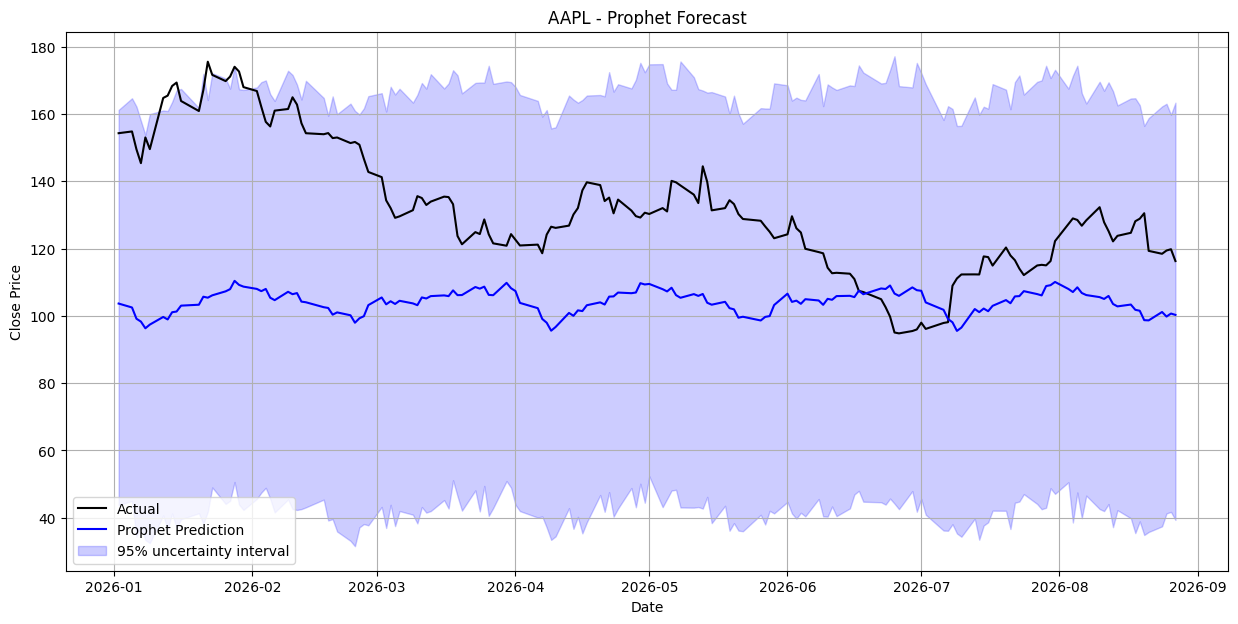

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

plt.plot(results["ds"],results["y"],label="Actual",color="black" )

plt.plot(results["ds"],results["yhat"],label="Prophet Prediction",color="blue")

plt.fill_between(results["ds"],results["yhat_lower"],results["yhat_upper"],color="blue",alpha=0.2,label="95% uncertainty interval")

plt.title("AAPL - Prophet Forecast")

plt.xlabel("Date")
plt.ylabel("Close Price")

plt.legend()
plt.grid(True)

plt.show()


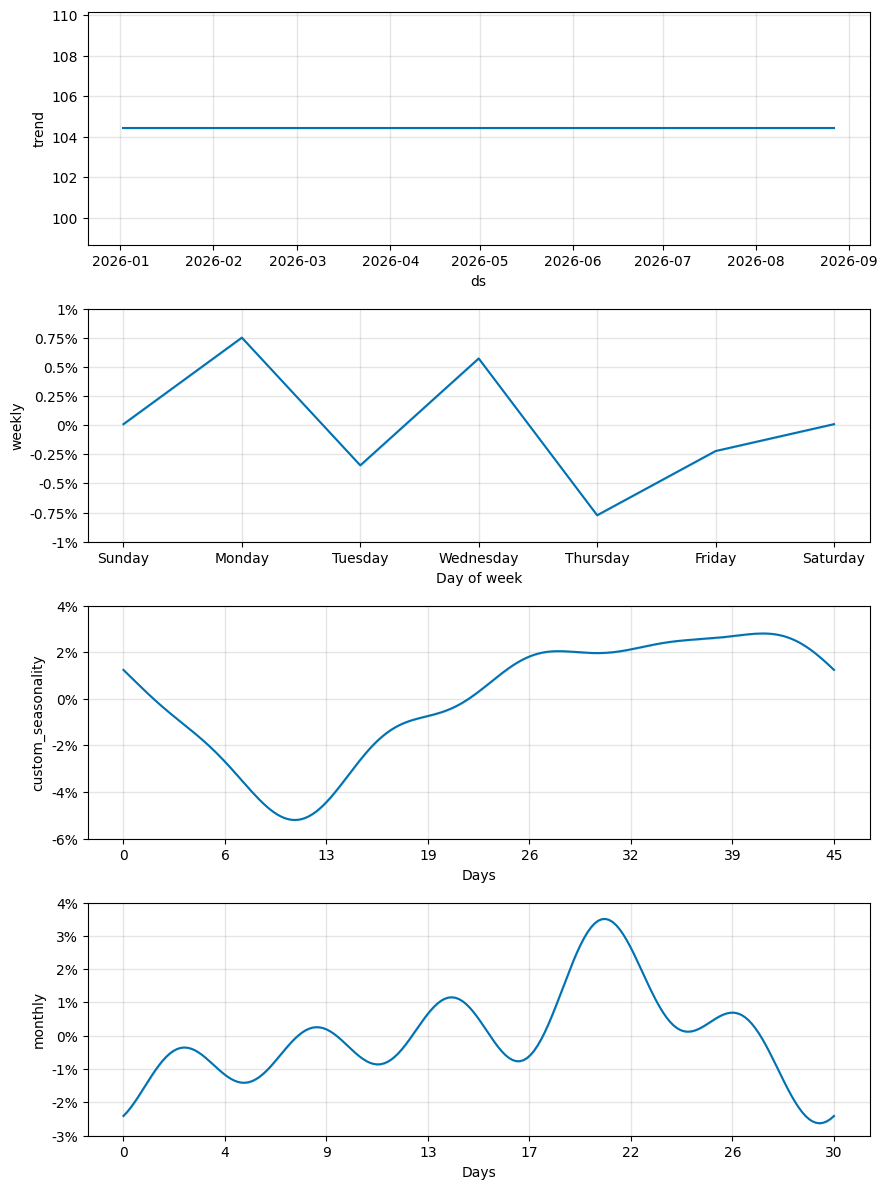

In [46]:
model.plot_components(forecast)

plt.show()

In [47]:
last_date = train["ds"].iloc[-1]
last_date


Timestamp('2025-12-31 00:00:00')

In [48]:
final_train = pd.concat(
    [train, test],
    ignore_index=True
)

final_train = final_train.sort_values("ds").reset_index(drop=True)

print(final_train["ds"].min())
print(final_train["ds"].max())

2024-01-02 00:00:00
2026-08-27 00:00:00


In [49]:
model1 = Prophet(
    growth="flat",
    yearly_seasonality='auto',
    weekly_seasonality='auto',
    daily_seasonality='auto',
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.1,
    changepoint_range=0.9,
    seasonality_prior_scale=10,
    interval_width=0.95,
    n_changepoints=50
)

In [50]:
model1.fit(final_train)

15:39:41 - cmdstanpy - INFO - Chain [1] start processing
15:39:41 - cmdstanpy - INFO - Chain [1] done processing


In [51]:
last_date = final_train["ds"].max()

future_dates = pd.date_range(  #bdate_range() means business date range.It generates dates for weekdays (Monday–Friday) rather than every calendar day.
    start=last_date + pd.Timedelta(days=1),
    periods=60
)

future = pd.DataFrame({
    "ds": future_dates
})

print(future.head())
print(future.tail())

          ds
0 2026-08-28
1 2026-08-29
2 2026-08-30
3 2026-08-31
4 2026-09-01
           ds
55 2026-10-22
56 2026-10-23
57 2026-10-24
58 2026-10-25
59 2026-10-26


In [52]:
future_forecast = model1.predict(future)

In [53]:
future_forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2026-08-28,112.519767,48.563653,160.337253,112.519767,112.519767,-0.058667,-0.058667,-0.058667,-0.004314,-0.004314,-0.004314,-0.054354,-0.054354,-0.054354,0.0,0.0,0.0,105.918526
1,2026-08-29,112.519767,44.934615,165.868320,112.519767,112.519767,-0.056180,-0.056180,-0.056180,0.000148,0.000148,0.000148,-0.056328,-0.056328,-0.056328,0.0,0.0,0.0,106.198432
2,2026-08-30,112.519767,44.598447,163.918582,112.519767,112.519767,-0.057666,-0.057666,-0.057666,0.000148,0.000148,0.000148,-0.057813,-0.057813,-0.057813,0.0,0.0,0.0,106.031237
3,2026-08-31,112.519767,45.154217,163.471953,112.519767,112.519767,-0.056200,-0.056200,-0.056200,0.002479,0.002479,0.002479,-0.058678,-0.058678,-0.058678,0.0,0.0,0.0,106.196189
4,2026-09-01,112.519767,44.388706,165.297006,112.519767,112.519767,-0.059754,-0.059754,-0.059754,-0.000962,-0.000962,-0.000962,-0.058792,-0.058792,-0.058792,0.0,0.0,0.0,105.796265
5,2026-09-02,112.519767,48.783486,164.843922,112.519767,112.519767,-0.051542,-0.051542,-0.051542,0.006491,0.006491,0.006491,-0.058033,-0.058033,-0.058033,0.0,0.0,0.0,106.720256
6,2026-09-03,112.519767,49.107189,159.585553,112.519767,112.519767,-0.060279,-0.060279,-0.060279,-0.003990,-0.003990,-0.003990,-0.056289,-0.056289,-0.056289,0.0,0.0,0.0,105.737193
7,2026-09-04,112.519767,47.405062,166.369084,112.519767,112.519767,-0.057774,-0.057774,-0.057774,-0.004314,-0.004314,-0.004314,-0.053460,-0.053460,-0.053460,0.0,0.0,0.0,106.019079
8,2026-09-05,112.519767,50.533281,166.728006,112.519767,112.519767,-0.049318,-0.049318,-0.049318,0.000148,0.000148,0.000148,-0.049465,-0.049465,-0.049465,0.0,0.0,0.0,106.970563
9,2026-09-06,112.519767,50.480821,162.892950,112.519767,112.519767,-0.044094,-0.044094,-0.044094,0.000148,0.000148,0.000148,-0.044242,-0.044242,-0.044242,0.0,0.0,0.0,107.558340


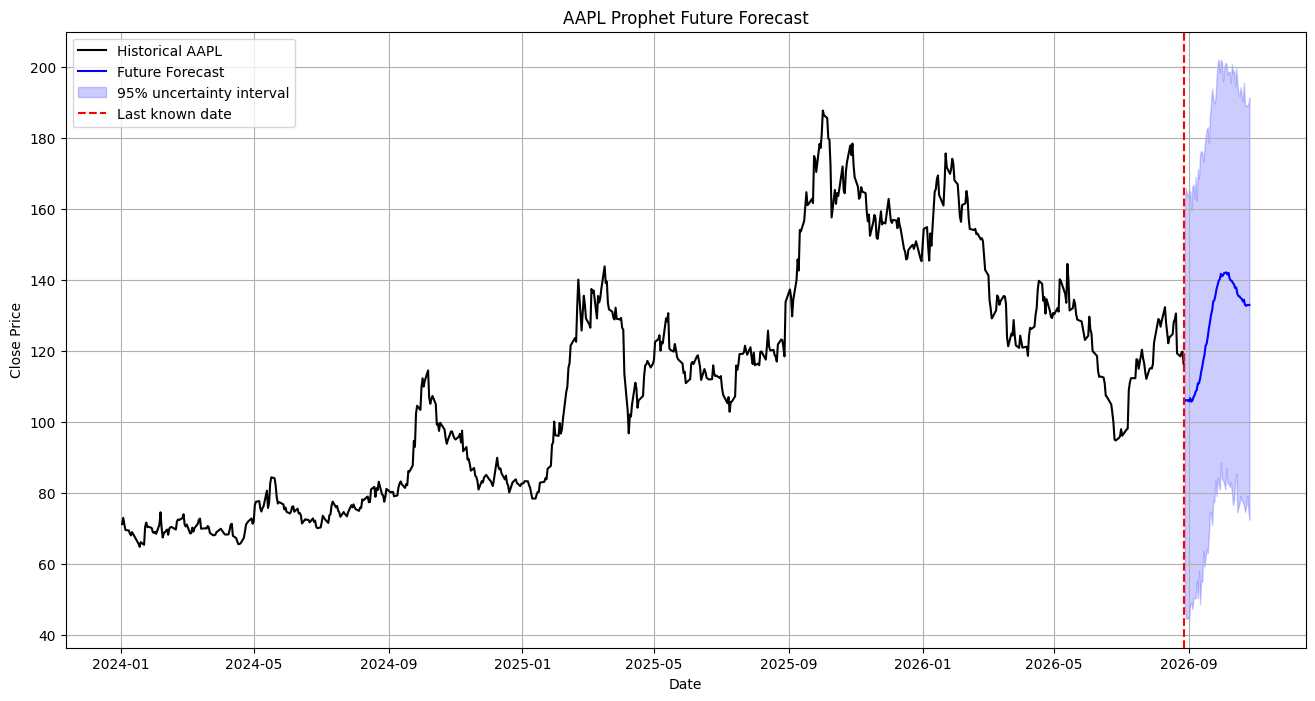

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

# Historical actual prices
plt.plot(
    final_train["ds"],
    final_train["y"],
    color="black",
    label="Historical AAPL"
)

# Future forecast
plt.plot(
    future_forecast["ds"],
    future_forecast["yhat"],
    color="blue",
    label="Future Forecast"
)

# Uncertainty interval
plt.fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    color="blue",
    alpha=0.2,
    label="95% uncertainty interval"
)

# Forecast starting point
plt.axvline(
    last_date,
    color="red",
    linestyle="--",
    label="Last known date"
)

plt.title("AAPL Prophet Future Forecast")

plt.xlabel("Date")
plt.ylabel("Close Price")

plt.legend()
plt.grid(True)

plt.show()
